# CIFAR-10 — Comparaison des optimiseurs
**Cours d'Optimisation Convexe — EFREI Paris**

Ce notebook compare le comportement de 5 optimiseurs sur CIFAR-10 :
SGD, SGD+Momentum, AdaGrad, RMSProp, Adam.

**Structure :**
1. Installation & imports
2. Configuration globale
3. Chargement des données
4. Architecture du modèle
5. Boucle d'entraînement
6. Lancement des expériences
7. Visualisation des résultats
8. Tableau récapitulatif

## 1. Installation & Imports

In [ ]:
# Uncomment if running on Colab
# !pip install torch torchvision matplotlib pandas

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import time
import copy

print(f"PyTorch version : {torch.__version__}")
print(f"Device disponible : {'GPU' if torch.cuda.is_available() else 'CPU'}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 2. Configuration globale

Tous les hyperparamètres sont centralisés ici pour faciliter la reproductibilité.

In [9]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

NUM_EPOCHS   = 5
BATCH_SIZE   = 128
NUM_WORKERS  = 2

# Optimiseurs :
OPTIMIZERS_CONFIG = [
    {
        "name"    : "SGD",
        "color"   : "#e41a1c",
        "cls"     : optim.SGD,
        "kwargs"  : {"lr": 0.01, "momentum": 0.0}
    },
    {
        "name"    : "SGD + Momentum",
        "color"   : "#ff7f00",
        "cls"     : optim.SGD,
        "kwargs"  : {"lr": 0.01, "momentum": 0.9}
    },
    {
        "name"    : "AdaGrad",
        "color"   : "#4daf4a",
        "cls"     : optim.Adagrad,
        "kwargs"  : {"lr": 0.01}
    },
    {
        "name"    : "RMSProp",
        "color"   : "#377eb8",
        "cls"     : optim.RMSprop,
        "kwargs"  : {"lr": 0.001, "alpha": 0.9}
    },
    {
        "name"    : "Adam",
        "color"   : "#984ea3",
        "cls"     : optim.Adam,
        "kwargs"  : {"lr": 0.001, "betas": (0.9, 0.999)}
    },
]

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Configuration chargée.")

Configuration chargée.


## 3. Chargement des données CIFAR-10

In [12]:
# ── Transformations ───────────────────────────────────────
# Normalisation par la moyenne et l'écart-type de CIFAR-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# ── Datasets ──────────────────────────────────────────────
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

CLASSES = ('avion', 'automobile', 'oiseau', 'chat', 'cerf',
           'chien', 'grenouille', 'cheval', 'bateau', 'camion')

print(f"Entraînement : {len(trainset):,} images")
print(f"Test         : {len(testset):,} images")

Entraînement : 50,000 images
Test         : 10,000 images


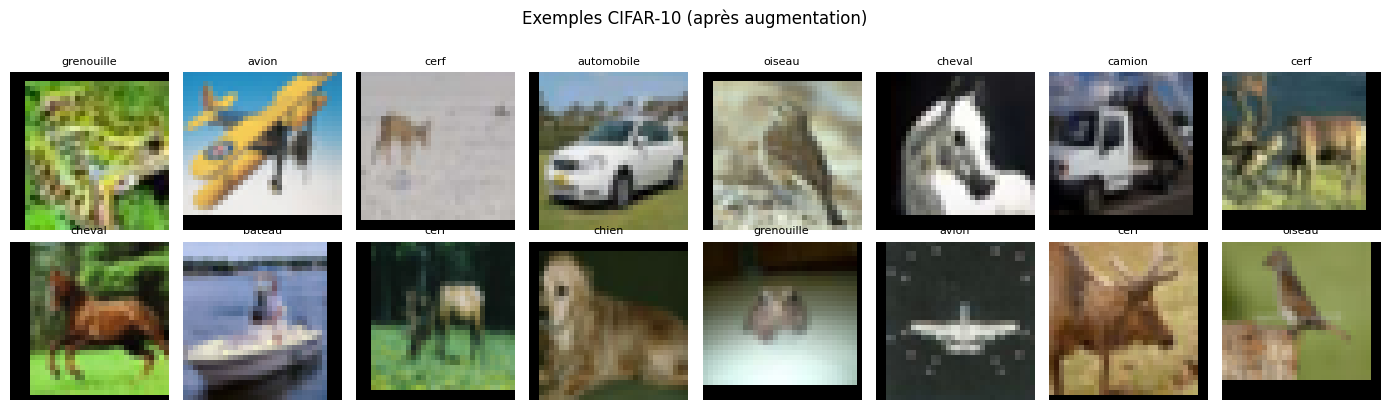

In [13]:
# ── Visualisation d'un batch ──────────────────────────────
def imshow(img):
    """Dénormalise et affiche un tenseur image."""
    mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR10_STD).view(3,1,1)
    img  = img * std + mean
    return img.permute(1, 2, 0).numpy().clip(0, 1)

images, labels = next(iter(trainloader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imshow(images[i]))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Exemples CIFAR-10 (après augmentation)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/cifar10_samples.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Architecture du modèle — CNN simple

On utilise un CNN léger mais suffisant pour observer les différences entre optimiseurs.
L'architecture est **fixe** pour tous les optimiseurs : seul l'optimiseur varie.

In [5]:
class SimpleCNN(nn.Module):
    """
    CNN à 3 blocs convolutifs + 2 couches fully-connected.
    Architecture identique pour toutes les expériences.
    """
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 32x32 → 16x16
            nn.Dropout2d(0.1),

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 16x16 → 8x8
            nn.Dropout2d(0.2),

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 8x8 → 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Vérification rapide ───────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_test_model = SimpleCNN().to(DEVICE)
_test_input = torch.randn(4, 3, 32, 32).to(DEVICE)
_test_out   = _test_model(_test_input)

print(f"Sortie shape     : {_test_out.shape}   (attendu : [4, 10])")
print(f"Paramètres total : {count_params(_test_model):,}")

Sortie shape     : torch.Size([4, 10])   (attendu : [4, 10])
Paramètres total : 667,178


## 5. Boucle d'entraînement

Fonction générique réutilisée pour chaque optimiseur. Elle retourne un dictionnaire
contenant l'historique complet (loss, accuracy, gradient norm) par epoch.

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Entraîne le modèle sur une epoch. Retourne loss, accuracy, grad_norm moyens."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    grad_norms = []

    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        # Norme du gradient (utile pour analyser le comportement de l'optimiseur)
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        grad_norms.append(total_norm ** 0.5)

        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)

    return (
        total_loss / total,
        100.0 * correct / total,
        float(np.mean(grad_norms))
    )


def evaluate(model, loader, criterion):
    """Evalue le modèle sur un loader. Retourne loss et accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss    = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total   += inputs.size(0)

    return total_loss / total, 100.0 * correct / total


def run_experiment(config, num_epochs=NUM_EPOCHS, verbose=True):
    """
    Lance une expérience complète pour un optimiseur donné.

    Paramètres
    ----------
    config : dict avec clés 'name', 'cls', 'kwargs'

    Retourne
    --------
    history : dict avec listes par epoch
    """
    torch.manual_seed(SEED)  # Même initialisation pour tous
    model     = SimpleCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = config["cls"](model.parameters(), **config["kwargs"])

    history = {
        "name"       : config["name"],
        "train_loss" : [], "train_acc" : [],
        "test_loss"  : [], "test_acc"  : [],
        "grad_norm"  : [],
    }

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, g_norm = train_one_epoch(model, trainloader, optimizer, criterion)
        te_loss, te_acc         = evaluate(model, testloader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)
        history["grad_norm"].append(g_norm)

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"  Epoch {epoch:>2}/{num_epochs} "
                  f"| train loss {tr_loss:.4f}  acc {tr_acc:.1f}% "
                  f"| test loss {te_loss:.4f}  acc {te_acc:.1f}%")

    elapsed = time.time() - t0
    history["elapsed_s"] = elapsed
    if verbose:
        print(f"  → Durée totale : {elapsed:.0f}s | Meilleure précision test : "
              f"{max(history['test_acc']):.2f}%\n")

    return history

print("Fonctions d'entraînement définies.")

Fonctions d'entraînement définies.


## 6. Lancement des expériences

On entraîne les 5 optimiseurs séquentiellement avec la même architecture et les mêmes données.

In [8]:
all_histories = []

for cfg in OPTIMIZERS_CONFIG:
    print(f"{'='*55}")
    print(f"  Optimiseur : {cfg['name']}  —  {cfg['kwargs']}")
    print(f"{'='*55}")
    hist = run_experiment(cfg, num_epochs=NUM_EPOCHS)
    all_histories.append(hist)

print("Toutes les expériences terminées.")

  Optimiseur : SGD  —  {'lr': 0.01, 'momentum': 0.0}
  Epoch  1/30 | train loss 1.9001  acc 29.5% | test loss 1.5555  acc 43.7%
  Epoch  5/30 | train loss 1.3743  acc 50.0% | test loss 1.1287  acc 60.1%
  Epoch 10/30 | train loss 1.1070  acc 60.5% | test loss 0.8852  acc 68.2%
  Epoch 15/30 | train loss 0.9599  acc 65.8% | test loss 0.7843  acc 72.1%
  Epoch 20/30 | train loss 0.8715  acc 69.3% | test loss 0.7371  acc 74.3%
  Epoch 25/30 | train loss 0.8019  acc 71.8% | test loss 0.6468  acc 77.3%
  Epoch 30/30 | train loss 0.7500  acc 73.8% | test loss 0.6140  acc 78.7%
  → Durée totale : 2677s | Meilleure précision test : 78.71%

  Optimiseur : SGD + Momentum  —  {'lr': 0.01, 'momentum': 0.9}
  Epoch  1/30 | train loss 1.6745  acc 37.8% | test loss 1.2466  acc 54.5%


KeyboardInterrupt: 

## 7. Visualisation des résultats

In [ ]:
EPOCHS = list(range(1, NUM_EPOCHS + 1))
COLORS = {cfg["name"]: cfg["color"] for cfg in OPTIMIZERS_CONFIG}

def plot_metric(ax, histories, metric, title, ylabel, colors):
    for h in histories:
        ax.plot(EPOCHS, h[metric], label=h["name"], color=colors[h["name"]], linewidth=2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

In [ ]:
# ── Figure 1 : Courbes de convergence ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Comparaison des optimiseurs — CIFAR-10', fontsize=14, fontweight='bold', y=1.01)

plot_metric(axes[0,0], all_histories, 'train_loss', 'Perte (entraînement)', 'Loss', COLORS)
plot_metric(axes[0,1], all_histories, 'test_loss',  'Perte (test)',         'Loss', COLORS)
plot_metric(axes[1,0], all_histories, 'train_acc',  'Précision (entraînement)', 'Accuracy (%)', COLORS)
plot_metric(axes[1,1], all_histories, 'test_acc',   'Précision (test)',          'Accuracy (%)', COLORS)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : results/learning_curves.png")

In [ ]:
# ── Figure 2 : Norme du gradient ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for h in all_histories:
    ax.plot(EPOCHS, h['grad_norm'], label=h['name'], color=COLORS[h['name']], linewidth=2)
ax.set_title('Évolution de la norme du gradient', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('||∇θ L||₂')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/grad_norms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : results/grad_norms.png")

In [ ]:
# ── Figure 3 : Écart de généralisation ────────────────────
# Généralisation gap = précision train - précision test
fig, ax = plt.subplots(figsize=(10, 4))
for h in all_histories:
    gap = [tr - te for tr, te in zip(h['train_acc'], h['test_acc'])]
    ax.plot(EPOCHS, gap, label=h['name'], color=COLORS[h['name']], linewidth=2)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Écart de généralisation (train acc − test acc)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gap (%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/generalization_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : results/generalization_gap.png")

In [ ]:
# ── Figure 4 : Précision test finale (barplot) ────────────
names       = [h['name'] for h in all_histories]
final_accs  = [max(h['test_acc']) for h in all_histories]
bar_colors  = [COLORS[n] for n in names]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, final_accs, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('Meilleure précision test par optimiseur', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/final_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : results/final_accuracy.png")

## 8. Tableau récapitulatif

In [ ]:
def epochs_to_threshold(history, metric, threshold):
    """Retourne le premier epoch où metric dépasse threshold, ou None."""
    for i, val in enumerate(history[metric]):
        if val >= threshold:
            return i + 1
    return None

rows = []
for h in all_histories:
    gap_final = h['train_acc'][-1] - h['test_acc'][-1]
    ep_70     = epochs_to_threshold(h, 'test_acc', 70.0)
    ep_75     = epochs_to_threshold(h, 'test_acc', 75.0)
    rows.append({
        "Optimiseur"         : h['name'],
        "Précision train (%)" : f"{h['train_acc'][-1]:.2f}",
        "Précision test (%)"  : f"{max(h['test_acc']):.2f}",
        "Écart génér. (%)"   : f"{gap_final:.2f}",
        "Epoch → 70%"        : ep_70  if ep_70  else ">" + str(NUM_EPOCHS),
        "Epoch → 75%"        : ep_75  if ep_75  else ">" + str(NUM_EPOCHS),
        "Durée (s)"          : f"{h['elapsed_s']:.0f}",
    })

df = pd.DataFrame(rows).set_index("Optimiseur")
display(df)

# Sauvegarde CSV pour le rapport
df.to_csv(f"{RESULTS_DIR}/summary_table.csv")
print("\nSauvegardé : results/summary_table.csv")

---
## Notes pour le rapport

Les figures générées sont dans le dossier `results/` :

| Fichier | Section du rapport |
|---|---|
| `cifar10_samples.png` | Section 4 — Protocole expérimental |
| `learning_curves.png` | Section 5.1 — Courbes de convergence |
| `grad_norms.png` | Section 5.4 — Normes des gradients |
| `generalization_gap.png` | Section 5.2 — Écart de généralisation |
| `final_accuracy.png` | Section 5.2 — Précision finale |
| `summary_table.csv` | Section 5.2 — Tableau de résultats |

Pour inclure une figure dans le rapport LaTeX :
```latex
\begin{figure}[H]
  \centering
  \includegraphics[width=\textwidth]{figures/learning_curves.png}
  \caption{Courbes d'entraînement et de validation pour les cinq optimiseurs.}
  \label{fig:curves}
\end{figure}
```